# Topic Modeling with Latent Dirichlet Allocation (LDA)

This notebook demonstrates topic modeling using the 20 Newsgroups dataset, a publicly available corpus of approximately 20,000 newsgroup documents across 20 different categories.

## Overview

Topic modeling is an unsupervised machine learning technique that discovers abstract "topics" within a collection of documents. We'll use **Latent Dirichlet Allocation (LDA)**, one of the most popular topic modeling algorithms.

## Steps:
1. Load and explore the data
2. Preprocess the text
3. Create a document-term matrix
4. Build and train the LDA model
5. Visualize and interpret the topics

## Step 1: Import Libraries and Load Data

In [1]:
# Standard library imports
import warnings
from typing import List, Tuple

# Third-party imports for data manipulation and NLP
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn for dataset and text processing
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure visualization settings
plt.style.use('ggplot')
sns.set_palette('husl')
%matplotlib inline

In [2]:
# Load a subset of the 20 newsgroups dataset
# We'll use 5 categories to make the topics more distinct and easier to interpret
categories = [
    'rec.sport.baseball',
    'sci.med',
    'comp.graphics',
    'talk.politics.guns',
    'sci.space'
]

# Fetch the dataset, removing headers/footers/quotes for cleaner text
newsgroups = fetch_20newsgroups(
    subset='all',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)

# Extract documents and create labels mapping
documents = newsgroups.data
category_names = newsgroups.target_names

print(f"Number of documents: {len(documents)}")
print(f"Categories: {category_names}")
print(f"\nSample document:\n{documents[0][:500]}...")

Number of documents: 4854
Categories: ['comp.graphics', 'rec.sport.baseball', 'sci.med', 'sci.space', 'talk.politics.guns']

Sample document:


There are two different mechanisms here:  toning of muscles and reduction of
fat.  Exercises specific to particular muscles will tone only those muscles
exercised (example: look at differences in arm circumferences between pitching
arms and non-pitching arms in major league pitchers).  However, if exercise
also leads to reduction of body fat, the loss of body fat will be equally
distributed over the entire body.  There is no way to "spot reduce" body fat
other than surgically, through liposuct...


## Step 2: Text Preprocessing

Before building our model, we need to:
- Convert text to lowercase
- Remove common words (stop words)
- Remove very rare and very common words
- Create a document-term matrix

In [3]:
# Create a CountVectorizer to convert documents into a matrix of token counts
# This is required for LDA, which expects count data (not TF-IDF)
vectorizer = CountVectorizer(
    max_df=0.95,          # Ignore terms that appear in >95% of documents
    min_df=2,             # Ignore terms that appear in <2 documents
    max_features=1000,    # Limit to top 1000 features
    stop_words='english', # Remove common English stop words
    lowercase=True        # Convert all text to lowercase
)

# Transform documents into document-term matrix
doc_term_matrix = vectorizer.fit_transform(documents)

# Extract feature names (vocabulary)
feature_names = vectorizer.get_feature_names_out()

print(f"Document-term matrix shape: {doc_term_matrix.shape}")
print(f"Number of unique terms: {len(feature_names)}")
print(f"\nSample terms: {list(feature_names[:20])}")

Document-term matrix shape: (4854, 1000)
Number of unique terms: 1000

Sample terms: ['00', '000', '01', '02', '03', '04', '05', '06', '10', '100', '11', '12', '128', '13', '14', '15', '16', '17', '18', '19']


## Step 3: Build and Train the LDA Model

LDA assumes:
- Each document is a mixture of topics
- Each topic is a mixture of words

We'll specify the number of topics we want to discover (in this case, 5 to match our categories).

In [4]:
# Initialize LDA model
n_topics = 5

lda_model = LatentDirichletAllocation(
    n_components=n_topics,      # Number of topics to extract
    max_iter=20,                # Maximum iterations for convergence
    learning_method='online',   # Use online variational Bayes
    random_state=42,
    batch_size=128,
    evaluate_every=-1,          # Don't evaluate perplexity (faster training)
    n_jobs=-1                   # Use all available CPU cores
)

# Fit the model to our document-term matrix
print("Training LDA model...")
lda_output = lda_model.fit_transform(doc_term_matrix)
print("Training complete!")

print(f"\nLDA output shape: {lda_output.shape}")
print("Each document is now represented as a distribution over {n_topics} topics")

Training LDA model...
Training complete!

LDA output shape: (4854, 5)
Each document is now represented as a distribution over {n_topics} topics


## Step 4: Examine the Discovered Topics

Each topic is represented as a distribution over words. Let's look at the top words for each topic.

In [5]:
def display_topics(
    model: LatentDirichletAllocation,
    feature_names: np.ndarray,
    n_top_words: int = 10
) -> None:
    """
    Display the top words for each topic discovered by the LDA model.
    
    Parameters:
    -----------
    model : LatentDirichletAllocation
        Trained LDA model
    feature_names : np.ndarray
        Array of feature names (vocabulary)
    n_top_words : int
        Number of top words to display per topic (default: 10)
    
    Returns:
    --------
    None
        Prints the topics to stdout
    """
    for topic_idx, topic in enumerate(model.components_):
        # Get indices of top words, sorted by weight
        top_indices = topic.argsort()[-n_top_words:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        
        print(f"\nTopic {topic_idx + 1}:")
        print(" | ".join(top_words))

# Display the topics
print("="*80)
print("DISCOVERED TOPICS")
print("="*80)
display_topics(lda_model, feature_names, n_top_words=10)

DISCOVERED TOPICS

Topic 1:
don | just | like | think | know | time | good | year | people | ve

Topic 2:
gun | people | use | medical | guns | law | control | cancer | disease | fbi

Topic 3:
space | nasa | earth | launch | shuttle | orbit | science | moon | mission | satellite

Topic 4:
edu | com | 10 | 1993 | 12 | information | 92 | 00 | 11 | april

Topic 5:
image | file | graphics | jpeg | images | software | gif | files | ftp | use


## Step 5: Visualize Topic Distributions

Let's visualize how topics are distributed across documents.

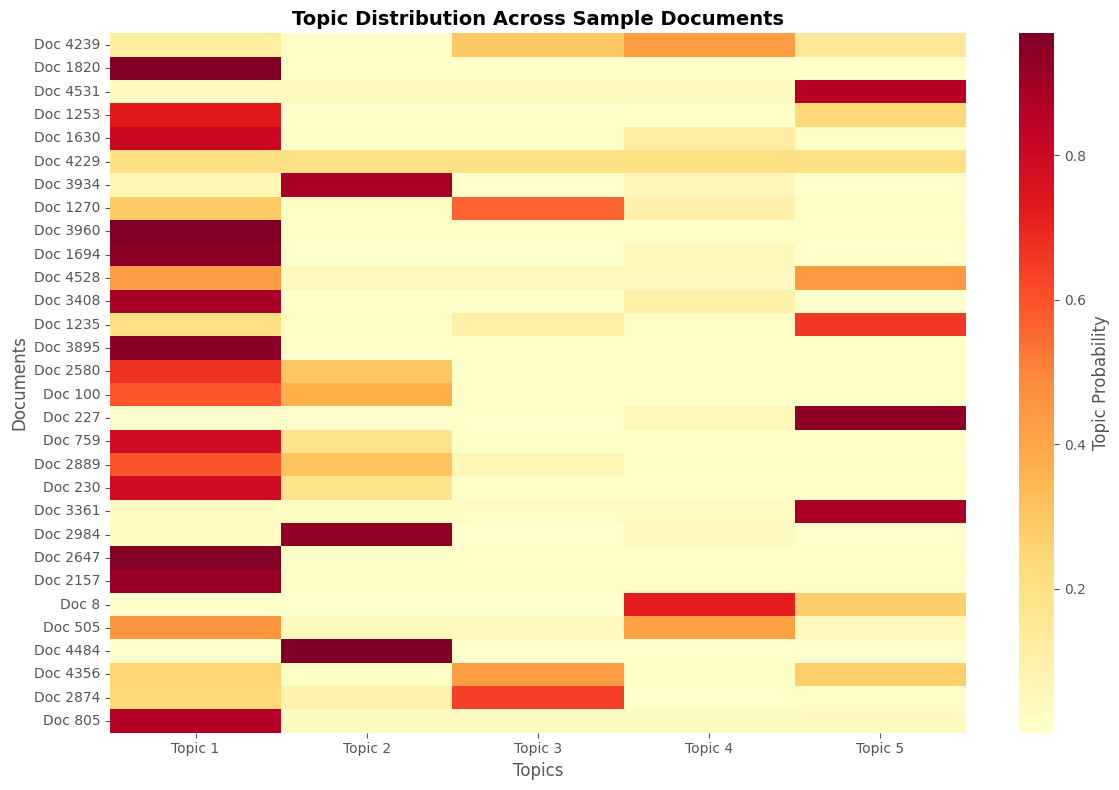

In [6]:
# Create a heatmap showing topic distribution for a sample of documents
n_docs_to_show = 30
sample_indices = np.random.choice(len(documents), n_docs_to_show, replace=False)

plt.figure(figsize=(12, 8))
sns.heatmap(
    lda_output[sample_indices],
    cmap='YlOrRd',
    cbar_kws={'label': 'Topic Probability'},
    xticklabels=[f'Topic {i+1}' for i in range(n_topics)],
    yticklabels=[f'Doc {i}' for i in sample_indices]
)
plt.title('Topic Distribution Across Sample Documents', fontsize=14, fontweight='bold')
plt.xlabel('Topics', fontsize=12)
plt.ylabel('Documents', fontsize=12)
plt.tight_layout()
plt.show()

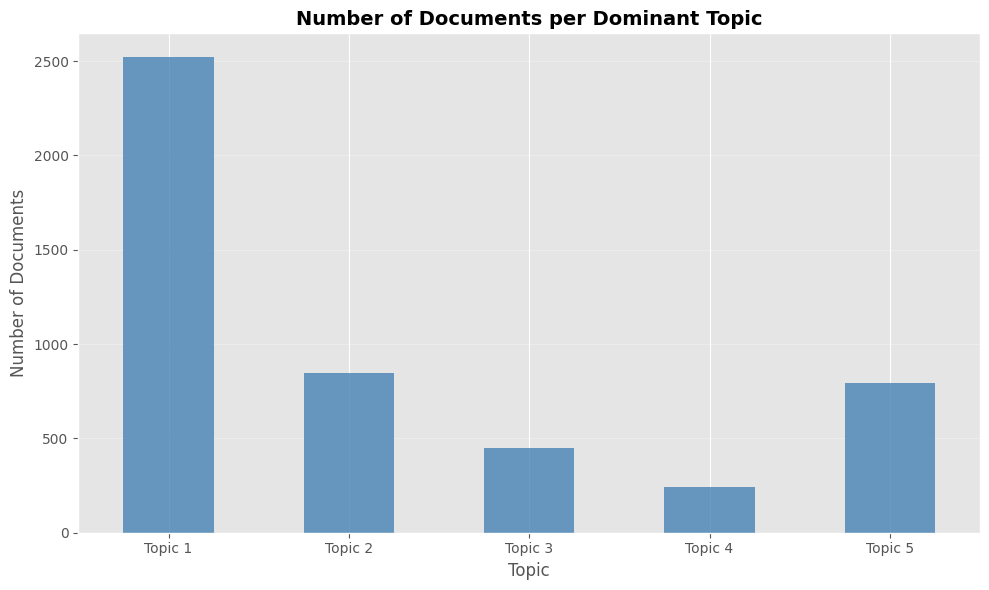


Documents per dominant topic:
Topic 1: 2521 documents
Topic 2: 844 documents
Topic 3: 451 documents
Topic 4: 243 documents
Topic 5: 795 documents


In [7]:
# Visualize the dominant topic for each document
dominant_topics = lda_output.argmax(axis=1)

# Count documents per topic
topic_counts = pd.Series(dominant_topics).value_counts().sort_index()

plt.figure(figsize=(10, 6))
topic_counts.plot(kind='bar', color='steelblue', alpha=0.8)
plt.title('Number of Documents per Dominant Topic', fontsize=14, fontweight='bold')
plt.xlabel('Topic', fontsize=12)
plt.ylabel('Number of Documents', fontsize=12)
plt.xticks([i for i in range(n_topics)], [f'Topic {i+1}' for i in range(n_topics)], rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nDocuments per dominant topic:")
for i in range(n_topics):
    count = topic_counts.get(i, 0)
    print(f"Topic {i+1}: {count} documents")

## Step 6: Analyze Sample Documents

Let's examine a few documents and their topic distributions to understand what the model learned.

In [8]:
def display_document_topics(
    doc_idx: int,
    documents: List[str],
    topic_distribution: np.ndarray,
    n_words: int = 100
) -> None:
    """
    Display a document with its topic distribution.
    
    Parameters:
    -----------
    doc_idx : int
        Index of the document to display
    documents : List[str]
        List of all documents
    topic_distribution : np.ndarray
        Topic distribution matrix from LDA
    n_words : int
        Number of words to display from the document (default: 100)
    
    Returns:
    --------
    None
        Prints the document and its topics to stdout
    """
    print(f"\n{'='*80}")
    print(f"Document {doc_idx}")
    print(f"{'='*80}")
    
    # Display document text (first n_words)
    words = documents[doc_idx].split()[:n_words]
    print(" ".join(words) + "...\n")
    
    # Display topic distribution
    print("Topic Distribution:")
    for topic_idx, prob in enumerate(topic_distribution[doc_idx]):
        print(f"  Topic {topic_idx + 1}: {prob:.3f}")
    
    # Display dominant topic
    dominant_topic = topic_distribution[doc_idx].argmax()
    print(f"\nDominant Topic: Topic {dominant_topic + 1}")

# Display 3 random sample documents
sample_doc_indices = np.random.choice(len(documents), 3, replace=False)
for idx in sample_doc_indices:
    display_document_topics(idx, documents, lda_output, n_words=50)


Document 3742
The gl2p1.lzh stuff under gfx/show on the Aminet sites includes a utility called pic2hl, that is a filter for HamLab that can handle the most commonly used kinds of .PIC and .CLP files. The biggest problem is that the .CLP files don't usually contain a palette, so you need to...

Topic Distribution:
  Topic 1: 0.012
  Topic 2: 0.012
  Topic 3: 0.012
  Topic 4: 0.012
  Topic 5: 0.952

Dominant Topic: Topic 5

Document 4317
A great deal of documentation exists on exactly that phenomenon. Especially regarding Vietnam and the Mai Lai (sp?) massacre Not that I'm suggesting that they started it on purpose but even if they now know that they accidentally started (or contributed to it) you can be sure the initial reaction...

Topic Distribution:
  Topic 1: 0.937
  Topic 2: 0.016
  Topic 3: 0.016
  Topic 4: 0.016
  Topic 5: 0.016

Dominant Topic: Topic 1

Document 1568
There is an excellent software program called Astro.calc that does that and much more. The latest address I have

## Step 7: Topic Coherence and Word Importance

Visualize the top words and their weights for each topic.

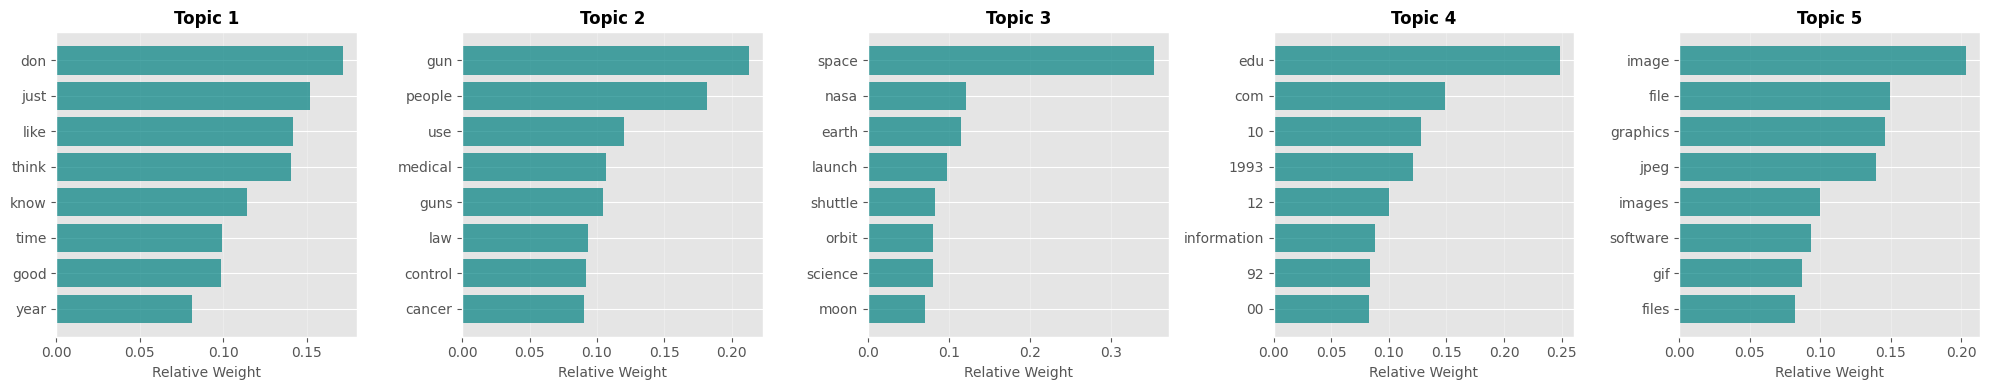

In [9]:
# Create a visualization of top words per topic with their weights
n_top_words = 8

fig, axes = plt.subplots(1, n_topics, figsize=(20, 4))

for topic_idx, (topic, ax) in enumerate(zip(lda_model.components_, axes)):
    # Get top words and their weights
    top_indices = topic.argsort()[-n_top_words:][::-1]
    top_words = [feature_names[i] for i in top_indices]
    top_weights = topic[top_indices]
    
    # Normalize weights for visualization
    top_weights = top_weights / top_weights.sum()
    
    # Create horizontal bar chart
    ax.barh(range(n_top_words), top_weights, color='teal', alpha=0.7)
    ax.set_yticks(range(n_top_words))
    ax.set_yticklabels(top_words)
    ax.invert_yaxis()
    ax.set_xlabel('Relative Weight', fontsize=10)
    ax.set_title(f'Topic {topic_idx + 1}', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated:

1. **Data Loading**: Using the 20 Newsgroups dataset as a publicly available corpus
2. **Preprocessing**: Converting text to a document-term matrix using CountVectorizer
3. **Model Training**: Building an LDA model to discover latent topics
4. **Topic Interpretation**: Examining the top words for each topic
5. **Visualization**: Creating heatmaps and charts to understand topic distributions
6. **Document Analysis**: Analyzing how individual documents map to topics

### Key Takeaways:

- **Topic modeling is unsupervised**: We don't need labeled data
- **Topics are interpretable**: The top words often reveal meaningful themes
- **Documents are mixtures**: Each document can belong to multiple topics
- **Hyperparameters matter**: The number of topics affects the granularity of themes discovered

### Next Steps:

- Experiment with different numbers of topics
- Try alternative preprocessing (lemmatization, custom stop words)
- Compare with other topic modeling algorithms (NMF, LSA)
- Use perplexity and coherence scores to evaluate model quality